# 00 - The reference image and the port detector

**What this notebook establishes.** Everything in Parts A-D rests on one detector,
so this notebook (a) extracts the reference raster losslessly from the PDF,
(b) *measures* the drawing rather than trusting the caption, and (c) builds and
validates the detector that the other four notebooks import.

The single most important finding here is that **the supplied drawing is
schematic, not metric**. That fact drives the modelling choice in notebook 03.

Contents: candidate approaches -> chosen approach -> measurements -> detector ->
validation -> limitations.

In [1]:
# --- Setup: locate the project, check dependencies, import the package -------
# Local Jupyter: the project is found by walking up from the working directory.
# Google Colab: Drive is mounted and searched for the project folder. A folder
# that cannot be written to (for example one shared as view-only) is copied to
# /content first, so the notebook can save its outputs.
import glob, importlib.util, os, shutil, subprocess, sys

PROJECT_NAME = "AULE_ComputerVisionChallenge"
PROJECT_DIR = ""  # optional: set this to the project folder if it is not found automatically

def _is_project(path):
    return bool(path) and os.path.isdir(os.path.join(path, "src", "aulecv"))

def _walk_up(start):
    path = os.path.abspath(start)
    while not _is_project(path):
        parent = os.path.dirname(path)
        if parent == path:
            return None
        path = parent
    return path

def _is_writable(path):
    probe = os.path.join(path, "outputs", ".write_test")
    try:
        os.makedirs(os.path.dirname(probe), exist_ok=True)
        with open(probe, "w") as fh:
            fh.write("ok")
        os.remove(probe)
        return True
    except OSError:
        return False

IN_COLAB = "google.colab" in sys.modules
PROJECT_ROOT = PROJECT_DIR if _is_project(PROJECT_DIR) else _walk_up(os.getcwd())

if PROJECT_ROOT is None and IN_COLAB:
    local_copy = os.path.join("/content", PROJECT_NAME)
    if _is_project(local_copy):
        PROJECT_ROOT = local_copy
    else:
        from google.colab import drive
        drive.mount("/content/drive")
        patterns = ["MyDrive/{}", "MyDrive/*/{}", "MyDrive/*/*/{}",
                    ".shortcut-targets-by-id/*/{}", ".shortcut-targets-by-id/*/*/{}",
                    "Shareddrives/*/{}"]
        found = [p for pat in patterns
                 for p in sorted(glob.glob(os.path.join("/content/drive", pat.format(PROJECT_NAME))))
                 if _is_project(p)]
        if not found:
            raise RuntimeError(
                "The {0} folder was not found in Google Drive. If it was shared with you, "
                "open Drive, right-click the shared folder and choose Organize > Add shortcut "
                "> My Drive, then run this cell again. Alternatively set PROJECT_DIR above."
                .format(PROJECT_NAME))
        PROJECT_ROOT = found[0]
        if not _is_writable(PROJECT_ROOT):
            shutil.copytree(PROJECT_ROOT, local_copy, dirs_exist_ok=True)
            print("Drive folder is read-only; working on a copy in", local_copy)
            PROJECT_ROOT = local_copy

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the {} folder. Open this notebook from inside it, "
                       "or set PROJECT_DIR above.".format(PROJECT_NAME))

_required = {"cv2": "opencv-python-headless", "numpy": "numpy", "pandas": "pandas",
             "matplotlib": "matplotlib", "imageio": "imageio", "PIL": "pillow"}
_missing = [pkg for mod, pkg in _required.items() if importlib.util.find_spec(mod) is None]
if _missing and IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _missing)
elif _missing:
    raise ImportError("Missing packages: {}. Install them with: pip install -r "
                      "requirements.txt".format(", ".join(_missing)))

os.environ["AULECV_PROJECT_ROOT"] = PROJECT_ROOT
if os.path.join(PROJECT_ROOT, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

import numpy as np, cv2, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

from aulecv import config as C, detect, rotation, navigation, camera, viz
from aulecv import io as aio

np.random.seed(C.RANDOM_SEED)
OUT = aio.ensure_output_dirs()
print("PROJECT_ROOT :", PROJECT_ROOT)
print("outputs      :", OUT)
print("python       :", sys.version.split()[0], "| opencv", cv2.__version__, "| numpy", np.__version__)

PROJECT_ROOT : D:\Aulespace\AULE_ComputerVisionChallenge
outputs      : D:\Aulespace\AULE_ComputerVisionChallenge\outputs
python       : 3.14.3 | opencv 4.13.0 | numpy 2.4.3


## 1. Getting the image: extraction, not screenshotting

The reference picture is an embedded raster object inside the assignment PDF
(object `xref` 9 on page 0). Re-rendering the PDF page at some DPI, or taking a
screenshot, would resample it and change every measurement we are about to make.

We pull the object's own byte stream out with PyMuPDF. The stream turns out to
already be a PNG, so `assets/reference.png` is written **byte-for-byte
identical** to what is inside the PDF.

In [2]:
import hashlib

ref_path = aio.asset_path("reference.png")
pdf_candidates = [os.environ.get("AULECV_ASSIGNMENT_PDF", ""),
                  os.path.join(PROJECT_ROOT, "Aule_ComputerVisionChallenge.pdf"),
                  aio.asset_path("Aule_ComputerVisionChallenge.pdf")]
pdf_path = next((p for p in pdf_candidates if os.path.isfile(p)), None)

if pdf_path is not None:
    out_path, info = aio.extract_reference_from_pdf(pdf_path)
    print("extracted from PDF :", info)
else:
    print("PDF not present in this environment; using the committed asset "
          "(it was produced by aulecv.io.extract_reference_from_pdf)")

reference = aio.load_reference()
raw = open(ref_path, "rb").read()
print("file              :", ref_path)
print("bytes on disk     :", len(raw))
print("md5 of file bytes :", hashlib.md5(raw).hexdigest())
print("decoded shape     :", reference.shape, reference.dtype)
assert reference.shape == (558, 604, 3)

PDF not present in this environment; using the committed asset (it was produced by aulecv.io.extract_reference_from_pdf)
file              : D:\Aulespace\AULE_ComputerVisionChallenge\assets\reference.png
bytes on disk     : 9154
md5 of file bytes : a50b8483ac5cacddf89100d2c25366df
decoded shape     : (558, 604, 3) uint8


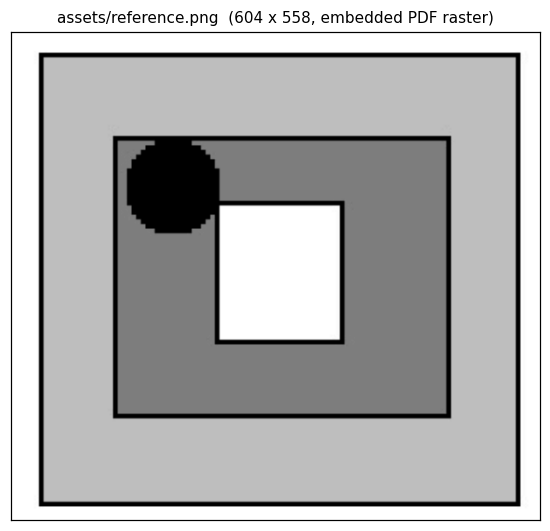

In [3]:
viz.show(reference, "assets/reference.png  (604 x 558, embedded PDF raster)", figsize=(6.2, 5.8))
plt.show()

## 2. Measuring the drawing (this is where the modelling choice comes from)

The assignment states: outer square 40 cm, innermost 30 cm, 2.5 cm spacing
(so the middle square is 35 cm). If the picture were a metric rendering of that
geometry, every square would be **square**, and the side ratios would be
40 : 35 : 30, i.e. 1.000 : 0.875 : 0.750.

Let us measure the three nested regions directly from the pixels instead of
assuming it.

In [4]:
gray = aio.to_gray(reference)
ink_all, ink_thr = detect.dark_mask(gray)
print("ink threshold chosen from the histogram (double Otsu):", ink_thr)

def runs_of_ink(line, min_len=2, merge_gap=2):
    """Start/end indices of the dark runs along a 1-D slice."""
    on = line > 0
    idx = np.flatnonzero(np.diff(on.astype(np.int8)))
    edges = []
    start = 0 if on[0] else None
    for i in idx:
        if on[i] and not on[i + 1]:
            edges.append((start, i + 1)); start = None
        elif (not on[i]) and on[i + 1]:
            start = i + 1
    if start is not None:
        edges.append((start, len(on)))
    merged = []
    for a, b in edges:
        if merged and a - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], b)
        else:
            merged.append((a, b))
    return [(a, b) for a, b in merged if b - a >= min_len]

cx, cy = np.round(detect.quad_center(detect.detect_outer_quad(gray)[0])).astype(int)
row_runs = runs_of_ink(ink_all[cy, :])
col_runs = runs_of_ink(ink_all[:, cx])
print("scanline through the port centre ({}, {})".format(cx, cy))
print("  horizontal ink runs:", row_runs)
print("  vertical   ink runs:", col_runs)
assert len(row_runs) == 6 and len(col_runs) == 6, (
    "expected 3 nested borders crossed twice on each scanline")

# Square k spans from the OUTER edge of run k to the outer edge of run (5-k).
rows = []
for k, name in enumerate(["outer", "middle", "inner"]):
    w = row_runs[5 - k][1] - row_runs[k][0]
    h = col_runs[5 - k][1] - col_runs[k][0]
    rows.append({"region": name, "w_px": w, "h_px": h, "aspect_w_over_h": w / h})

meas = pd.DataFrame(rows)
meas["side_vs_outer_measured"] = meas["w_px"] / meas["w_px"].iloc[0]
meas["side_cm_from_text"] = [C.OUTER_SIDE_CM, C.MIDDLE_SIDE_CM, C.INNER_SIDE_CM]
meas["side_vs_outer_from_text"] = meas["side_cm_from_text"] / C.OUTER_SIDE_CM
display(meas.round(4))

ink threshold chosen from the histogram (double Otsu): 65.0
scanline through the port centre (306, 283)
  horizontal ink runs: [(np.int64(32), np.int64(37)), (np.int64(117), np.int64(122)), (np.int64(233), np.int64(238)), (np.int64(376), np.int64(381)), (np.int64(497), np.int64(502)), (np.int64(577), np.int64(581))]
  vertical   ink runs: [(np.int64(25), np.int64(30)), (np.int64(120), np.int64(125)), (np.int64(194), np.int64(199)), (np.int64(353), np.int64(358)), (np.int64(437), np.int64(442)), (np.int64(537), np.int64(542))]


,region,w_px,h_px,aspect_w_over_h,side_vs_outer_measured,side_cm_from_text,side_vs_outer_from_text
0,outer,549,517,1.0619,1.0000,40.0,1.000
1,middle,385,322,1.1957,0.7013,35.0,0.875
2,inner,148,164,0.9024,0.2696,30.0,0.750


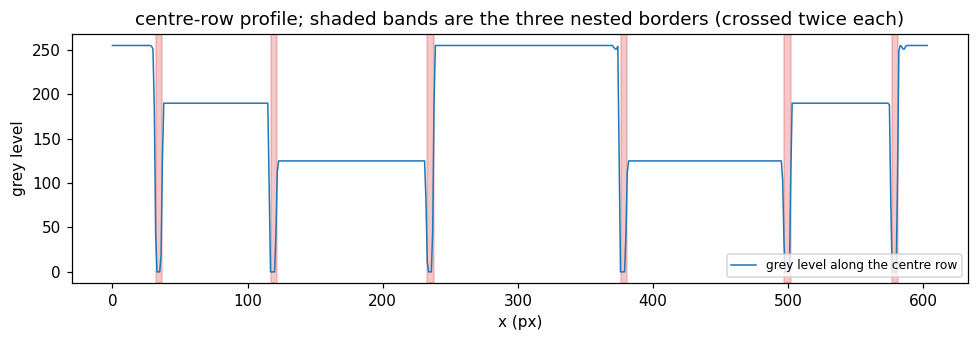

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(gray[cy, :], lw=1.0, label="grey level along the centre row")
for a, b in row_runs:
    ax.axvspan(a, b, color="tab:red", alpha=0.25)
ax.set_xlabel("x (px)"); ax.set_ylabel("grey level")
ax.set_title("centre-row profile; shaded bands are the three nested borders "
             "(crossed twice each)")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig(aio.output_path("detection", "centre_row_profile.png"),
            bbox_inches="tight", dpi=110)
plt.show()

Read the `aspect_w_over_h` column. A metric rendering would show `1.000` on
every row. It does not. And `side_vs_outer_measured` does not match
`side_vs_outer_from_text` either.

**Conclusion (used throughout):** the picture is a schematic illustration of the
port, not a calibrated photograph of it. Two consequences:

1. Any model that *derives* metric sizes from the raster will contradict the
   40/35/30 cm geometry we were given. Notebook 03 keeps the given geometry and
   attaches the raster to it as a texture.
2. The ~6% rectangularity of the outer region is a **drawing artefact**. It does
   leak orientation information (a square has no long edge, a rectangle does),
   which is why notebook 01 reports that cue as an *experiment* and never uses it
   in the estimator.

In [6]:
# Is the marker round, or is it stretched the same way the squares are?
# (If a single sensor aspect ratio explained the rectangularity, the marker
#  would have to be stretched by that same ratio.)
ink, thr = detect.dark_mask(gray)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
blob = max(cv2.findContours(cv2.morphologyEx(ink, cv2.MORPH_OPEN, k),
                            cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0],
           key=cv2.contourArea)
(mx, my), (a1, a2), ang = cv2.fitEllipse(blob)
bx, by, bw, bh = cv2.boundingRect(blob)
print("marker bounding box      : {} x {} px   (w/h = {:.3f})".format(bw, bh, bw / bh))
print("marker fitted ellipse    : axes {:.2f} x {:.2f} px  (minor/major = {:.3f})"
      .format(max(a1, a2), min(a1, a2), min(a1, a2) / max(a1, a2)))
print("outer region aspect w/h  : {:.3f}".format(meas['aspect_w_over_h'].iloc[0]))
print()
print("A non-square-pixel sensor with fx/fy = {:.3f} would stretch the circle by"
      .format(meas['aspect_w_over_h'].iloc[0]))
print("that same factor. The measured circle is {:.3f} -- it is round."
      .format(bw / bh))
print("So the rectangularity is drawing inaccuracy, not camera calibration.")

marker bounding box      : 107 x 111 px   (w/h = 0.964)
marker fitted ellipse    : axes 110.54 x 106.95 px  (minor/major = 0.967)
outer region aspect w/h  : 1.062

A non-square-pixel sensor with fx/fy = 1.062 would stretch the circle by
that same factor. The measured circle is 0.964 -- it is round.
So the rectangularity is drawing inaccuracy, not camera calibration.


## 3. The detector

### Candidate approaches considered

| Approach | Why not (or why yes) |
|---|---|
| Corner detection (Harris / Shi-Tomasi) on the whole image | Fires on all three nested squares and on the marker's silhouette; needs a separate grouping step to decide which 4 points are *the* outer corners. |
| `HoughLines` + line grouping | Works, but the four long borders each produce several accumulator peaks at this stroke thickness; picking 4 from ~10 is fiddly. |
| Template matching of the whole port | Not rotation- or scale-invariant; also circular, since it presumes the answer. |
| **Largest external contour -> `approxPolyDP` -> per-side `fitLine`** | **Chosen.** One unambiguous object (the port is the only thing on the page), sub-pixel corners from line intersections, and the fit uses hundreds of edge samples per side rather than one corner pixel. |
| Marker: threshold + circularity alone | Rejected as the *primary* cue: circularity is only 0.83 here (see below). |
| **Marker: disk opening -> `fitEllipse`, cross-checked by distance transform and `HoughCircles`** | **Chosen.** The opening is what separates the marker from the borders it touches. |

### Why the marker needs an opening at all

The marker "touches the innermost and the middle squares", so in the ink mask it
is **one connected component with both square borders**. Simple connected-component
labelling returns a single sprawling blob. A morphological opening with a disk of
diameter `MARKER_OPEN_DIAM_FACTOR x border_thickness` erases strokes thinner than
the disk and leaves the marker standing.

Note the chain: the kernel is sized from the *measured* border thickness, which
is itself measured from the distance transform of the ink mask. Nothing is a
magic number.

In [7]:
det = detect.detect_port(reference)

print("outer quad (canonical order: marker corner first, then clockwise)")
print(np.round(det.quad, 3))
print()
print("port centre (diagonal intersection) :", np.round(det.center, 3))
print("side lengths (px)                   :", np.round(det.side_lengths, 2))
print("mean outer side (px)                :", round(det.outer_side_px, 2))
print("border thickness (px)               :", round(det.border_thickness_px, 3),
      " = {:.4f} x outer side".format(det.border_thickness_px / det.outer_side_px))
print()
print("marker centre (fitEllipse)          :", np.round(det.marker_center, 3))
print("marker axes (major, minor) px       :", tuple(round(v, 2) for v in det.marker_axes))
print("marker mean radius (px)             :", round(det.marker_radius_px, 3))
print("marker circularity 4*pi*A/P^2       :", round(det.marker_circularity, 4))
print("marker minor/major                  :", round(det.marker_axis_ratio, 4))
print()
print("confidence                          :", round(det.confidence, 4))
for k, v in det.confidence_terms.items():
    print("    {:<28s} {:.4f}".format(k, v))
for n in det.notes:
    print("  note:", n)

outer quad (canonical order: marker corner first, then clockwise)
[[ 31.  24.]
 [581.  24.]
 [581. 542.]
 [ 31. 542.]]

port centre (diagonal intersection) : [306. 283.]
side lengths (px)                   : [550. 518. 550. 518.]
mean outer side (px)                : 534.0
border thickness (px)               : 6.0  = 0.0112 x outer side

marker centre (fitEllipse)          : [185.016 176.499]
marker axes (major, minor) px       : (110.15, 106.74)
marker mean radius (px)             : 54.223
marker circularity 4*pi*A/P^2       : 0.8337
marker minor/major                  : 0.9691

confidence                          : 0.9385
    quad_opposite_sides          1.0000
    corners_refined              1.0000
    marker_shape                 1.0000
    marker_dt_offset_px          1.0007
    marker_agreement             0.9385
    marker_hough_offset_px       5.5750
    marker_hough_agreement       0.7944


### Why the circularity threshold is lenient

The measured circularity of the true marker is printed above and is well below 1.
Two reasons, both visible in the raster: the outline is stair-stepped (the image
has been upscaled at some point), which inflates the perimeter `P`; and the disk
*bulges* where it merges with the two borders. So `config.MARKER_CIRCULARITY_MIN`
is set to 0.70 and circularity is only ever one cue among several -- the fitted
ellipse, the distance-transform peak and `HoughCircles` all have to agree.

In [8]:
print("cross-checks on the marker centre (all measured on this image):")
print("  fitEllipse            :", np.round(det.marker_center, 3))
print("  distance-transform pk :", np.round(det.marker_center_dt, 3),
      "   offset {:.3f} px".format(float(np.linalg.norm(det.marker_center - det.marker_center_dt))))
if det.marker_center_hough is not None:
    print("  HoughCircles          :", np.round(det.marker_center_hough, 3),
          "   offset {:.3f} px".format(float(np.linalg.norm(det.marker_center - det.marker_center_hough))))
else:
    print("  HoughCircles          : no circle returned in the radius band")
print()
print("The ellipse and the distance transform are two readings of the same blob,")
print("so they get the tight budget ({:.0%} of the radius) and set the confidence."
      .format(C.MARKER_CENTER_AGREE_FRAC))
print("HoughCircles votes into an integer accumulator over a coarse radius band,")
print("so it gets a looser budget ({:.0%}) and is reported, not scored."
      .format(C.MARKER_HOUGH_AGREE_FRAC))

cross-checks on the marker centre (all measured on this image):
  fitEllipse            : [185.016 176.499]
  distance-transform pk : [185.  177.5]    offset 1.001 px
  HoughCircles          : [190.5 177.5]    offset 5.575 px

The ellipse and the distance transform are two readings of the same blob,
so they get the tight budget (30% of the radius) and set the confidence.
HoughCircles votes into an integer accumulator over a coarse radius band,
so it gets a looser budget (50%) and is reported, not scored.


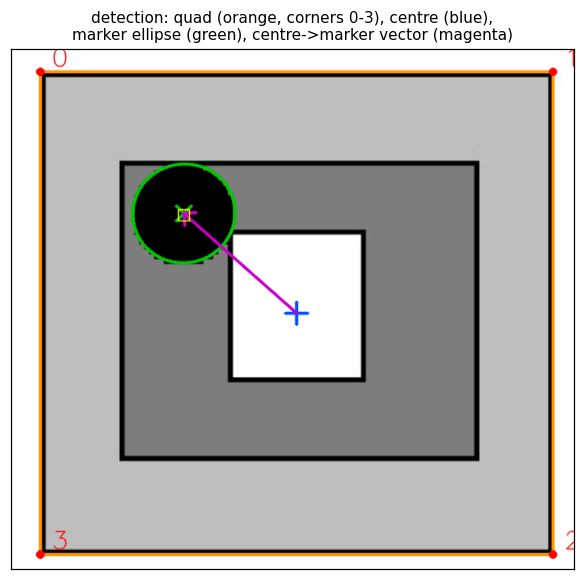

In [9]:
overlay = viz.draw_detection(reference, det)
aio.save_image(aio.output_path("detection", "reference_detection.png"), overlay)
viz.show(overlay, "detection: quad (orange, corners 0-3), centre (blue),\n"
                  "marker ellipse (green), centre->marker vector (magenta)",
         figsize=(6.6, 6.2))
plt.show()

### Canonical corner ordering

Corner `0` is the quad vertex nearest the marker; the rest follow clockwise on
screen. This matters more than it looks:

* it gives the port a **body frame** that survives arbitrary rotation, which is
  what makes Part A's refinement and Part C's texture map `G` well-defined;
* it is derived from the image content (where the marker is), not from where
  the corner happens to sit in the picture.

Notebook 01's test `test_canonical_order_follows_the_port_through_rotation`
confirms corner `k` stays the same physical corner through a rotation.

In [10]:
print("marker is nearest to quad vertex index :", det.marker_corner_index,
      "(of the image-ordered quad)")
print()
for i, p in enumerate(det.quad):
    print("  canonical corner {} : {}   distance to marker {:7.2f} px"
          .format(i, np.round(p, 2),
                  float(np.linalg.norm(p - det.marker_center))))

marker is nearest to quad vertex index : 0 (of the image-ordered quad)

  canonical corner 0 : [31. 24.]   distance to marker  216.74 px
  canonical corner 1 : [581.  24.]   distance to marker  424.33 px
  canonical corner 2 : [581. 542.]   distance to marker  538.88 px
  canonical corner 3 : [ 31. 542.]   distance to marker  396.63 px


## 4. Validation: does the detector survive real degradations?

Every number below is measured by running the detector; the pass criteria are
fractions of the detected geometry, never absolute pixel budgets.

In [11]:
rng = np.random.default_rng(C.RANDOM_SEED)
variants = {}
variants["original"] = reference
for s in (0.5, 0.75, 1.25, 1.5):
    variants["scale x{:g}".format(s)] = cv2.resize(
        reference, None, fx=s, fy=s,
        interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC)
for sg in (4.0, 10.0, 16.0):
    variants["noise sigma={:g}".format(sg)] = np.clip(
        reference.astype(np.float32) + rng.normal(0, sg, reference.shape), 0, 255).astype(np.uint8)
variants["blur sigma=2"] = cv2.GaussianBlur(reference, (0, 0), 2.0)
variants["blur sigma=4"] = cv2.GaussianBlur(reference, (0, 0), 4.0)
for q in (70, 35):
    ok, buf = cv2.imencode(".jpg", reference, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    variants["jpeg q={}".format(q)] = cv2.imdecode(buf, cv2.IMREAD_COLOR)
for a in (17.0, 90.0, 243.0):
    variants["rotated {:g} deg".format(a)] = rotation.rotate_image(reference, a)

# The marker *vector* is expressed in image axes, so it necessarily changes
# under rotation.  The rotation- and scale-invariant quantity is its LENGTH
# relative to the outer side, together with the marker's relative radius.
ref_rel = float(np.linalg.norm(det.marker_vector) / det.outer_side_px)
ref_radius_rel = float(det.marker_radius_px / det.outer_side_px)
print("reference invariants:  |centre->marker| / outer side = {:.5f}"
      "   marker radius / outer side = {:.5f}".format(ref_rel, ref_radius_rel))
rows, panels, titles = [], [], []
for name, img in variants.items():
    try:
        d = detect.detect_port(img)
        rel = (float(np.linalg.norm(d.marker_vector) / d.outer_side_px)
               if d.marker_found else np.nan)
        rad = (float(d.marker_radius_px / d.outer_side_px) if d.marker_found else np.nan)
        rows.append({
            "variant": name,
            "marker_found": d.marker_found,
            "outer_side_px": round(d.outer_side_px, 2),
            "border_px": round(d.border_thickness_px, 2),
            "circularity": round(d.marker_circularity, 3) if d.marker_found else np.nan,
            "confidence": round(d.confidence, 3),
            "marker_dist_rel_err": round(abs(rel - ref_rel), 5),
            "marker_radius_rel_err": round(abs(rad - ref_radius_rel), 5),
        })
        panels.append(viz.draw_detection(img, d, label_corners=False))
        titles.append("{}\nconf {:.2f}".format(name, d.confidence))
    except Exception as exc:
        rows.append({"variant": name, "marker_found": False, "outer_side_px": np.nan,
                     "border_px": np.nan, "circularity": np.nan, "confidence": 0.0,
                     "marker_dist_rel_err": np.nan, "marker_radius_rel_err": np.nan})
        print("FAILED on", name, ":", exc)

robust = pd.DataFrame(rows)
display(robust)
print("\ndetected on {} / {} variants".format(int(robust['marker_found'].sum()), len(robust)))
print("worst |centre->marker|/side error           : {:.5f}"
      .format(float(np.nanmax(robust['marker_dist_rel_err']))))
print("worst marker-radius/side error              : {:.5f}"
      .format(float(np.nanmax(robust['marker_radius_rel_err']))))
print("lowest confidence                           : {:.3f}".format(robust['confidence'].min()))

reference invariants:  |centre->marker| / outer side = 0.30184   marker radius / outer side = 0.10154


,variant,marker_found,outer_side_px,border_px,circularity,confidence,marker_dist_rel_err,marker_radius_rel_err
0,original,True,534.00,6.00,0.834,0.938,0.00000,0.00000
1,scale x0.5,True,267.00,2.00,0.848,0.972,0.00045,0.00059
2,scale x0.75,True,401.00,4.00,0.894,0.922,0.00071,0.00056
3,scale x1.25,True,668.00,6.00,0.811,0.935,0.00032,0.00030
4,scale x1.5,True,802.50,8.00,0.852,0.926,0.00004,0.00006
5,noise sigma=4,True,534.00,6.00,0.833,0.910,0.00001,0.00004
6,noise sigma=10,True,534.04,6.00,0.830,0.940,0.00017,0.00001
7,noise sigma=16,True,534.71,6.00,0.830,0.967,0.00100,0.00029
8,blur sigma=2,True,538.50,4.00,0.891,0.955,0.00160,0.00099
9,blur sigma=4,True,544.50,5.44,0.906,0.967,0.00505,0.00111



detected on 15 / 15 variants
worst |centre->marker|/side error           : 0.00505
worst marker-radius/side error              : 0.00111
lowest confidence                           : 0.907


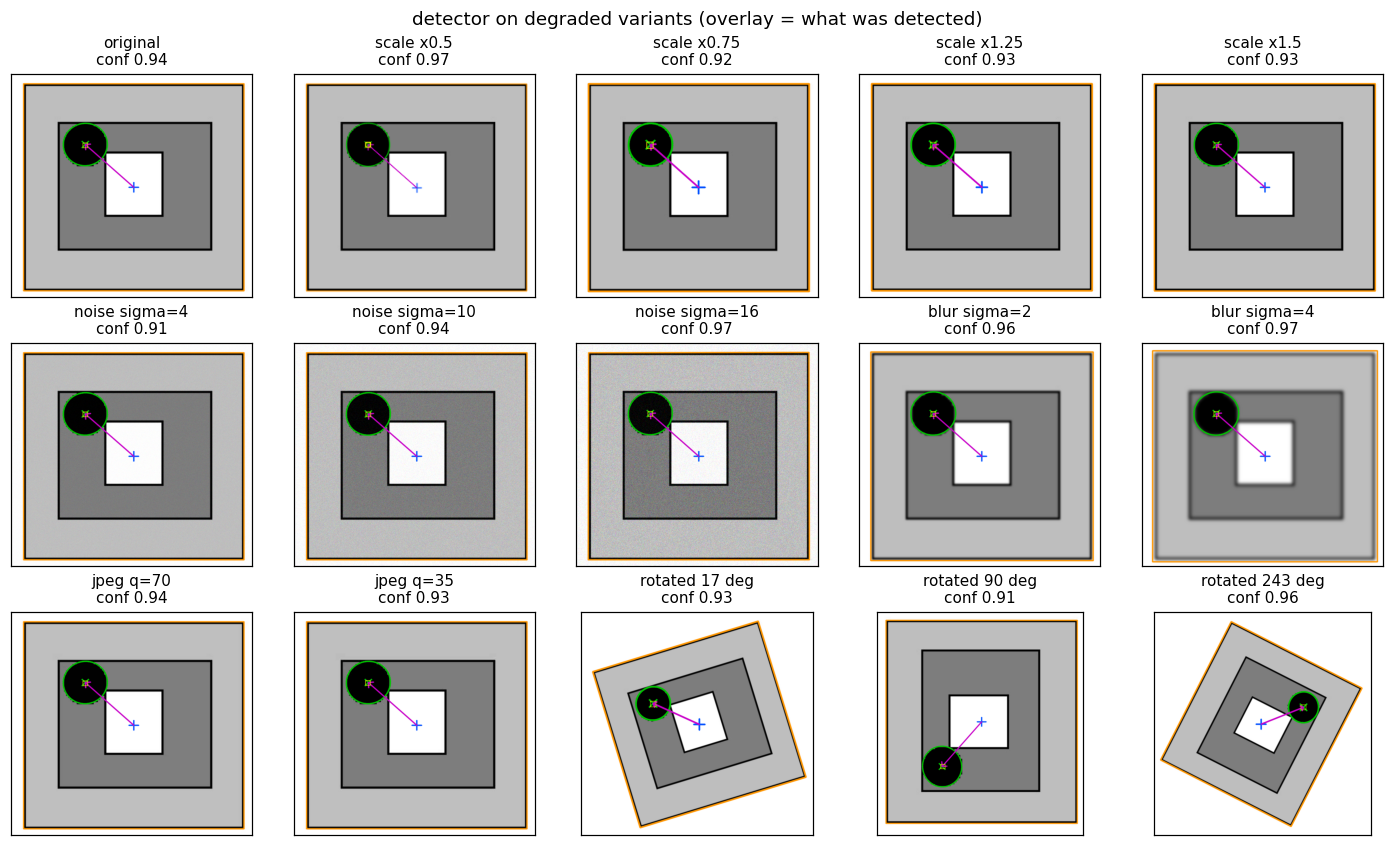

In [12]:
fig = viz.grid(panels, titles, cols=5, figsize_per=2.6,
               suptitle="detector on degraded variants (overlay = what was detected)")
fig.savefig(aio.output_path("detection", "robustness_grid.png"), bbox_inches="tight", dpi=110)
plt.show()

In [13]:
summary = pd.DataFrame([{
    "image_w": reference.shape[1], "image_h": reference.shape[0],
    "outer_side_px": det.outer_side_px,
    "outer_w_px": 0.5 * (np.linalg.norm(det.quad[1] - det.quad[0]) + np.linalg.norm(det.quad[2] - det.quad[3])),
    "outer_h_px": 0.5 * (np.linalg.norm(det.quad[2] - det.quad[1]) + np.linalg.norm(det.quad[3] - det.quad[0])),
    "border_thickness_px": det.border_thickness_px,
    "centre_x": det.center[0], "centre_y": det.center[1],
    "marker_x": det.marker_center[0], "marker_y": det.marker_center[1],
    "marker_radius_px": det.marker_radius_px,
    "marker_circularity": det.marker_circularity,
    "marker_axis_ratio": det.marker_axis_ratio,
    "marker_polar_deg": det.marker_angle_from_center_deg,
    "edge_angle_mod90_deg": det.edge_angle_mod90_deg(),
    "long_edge_mod180_deg": det.long_edge_angle_mod180_deg(),
    "confidence": det.confidence,
}]).round(4)
summary.to_csv(aio.output_path("detection_summary.csv"), index=False)
robust.to_csv(aio.output_path("detection", "robustness.csv"), index=False)
meas.round(4).to_csv(aio.output_path("detection", "drawing_measurements.csv"), index=False)
display(summary.T.rename(columns={0: "measured"}))
print("\nwrote outputs/detection_summary.csv, outputs/detection/robustness.csv, "
      "outputs/detection/drawing_measurements.csv")

,measured
image_w,604.0000
image_h,558.0000
outer_side_px,534.0000
outer_w_px,550.0000
outer_h_px,518.0000
border_thickness_px,6.0000
centre_x,306.0000
centre_y,283.0000
marker_x,185.0155
marker_y,176.4995



wrote outputs/detection_summary.csv, outputs/detection/robustness.csv, outputs/detection/drawing_measurements.csv


## 5. Limitations

* **The drawing is schematic.** The measured side ratios and aspect ratios do not
  match the stated 40/35/30 cm geometry. Everything downstream keeps the *stated*
  geometry and treats the raster as a texture.
* **One marker, one object.** The detector assumes a single port occupying most
  of the frame, on a roughly uniform page. It is not a general object detector.
* **No mirroring.** The canonical ordering assumes the view is not mirrored; a
  flipped image would reverse the clockwise ordering.
* **Confidence is a heuristic**, not a calibrated probability. It is the minimum
  of four normalised agreement terms; use it for triage, not for inference.
* **`quad_opposite_sides` penalises genuine perspective.** It is a squareness
  prior, so on the deliberately foreshortened renders of notebook 03 it drops
  below 1 *by design*. That is the near/far ratio, not a detection failure.